# drought

## to have year wise data based on event extend

In [1]:
import pandas as pd
from datetime import datetime
import numpy as np

em_data_filepath='emdat_public_2022_08_11_query_uid-IKGfZc.xlsx'

dfb = pd.read_excel(em_data_filepath, engine='openpyxl',skiprows=6,sheet_name = 'emdat data')

dfb_dr=dfb[dfb['Disaster Type']=='Drought']

ea_cntr=['Djibouti', 'Eritrea','Ethiopia','Kenya','Rwanda', 'Somalia','South Sudan','Sudan (the)','Tanzania, United Republic of']

#dfb1_ea=dfb1[dfb1['Country'].str.contains(ea_cntr)]
dfb_dr_ea=dfb_dr[dfb_dr['Country'].isin(ea_cntr)]
#dfb_dr_ea.info()

dfb_dr_ea_time=dfb_dr_ea[['Dis No','Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month','End Day']]
#dfb_dr_ea_time['Start Month'].tolist()
dfb_dr_ea_time['Start Month']=dfb_dr_ea_time['Start Month'].fillna(1.0)
dfb_dr_ea_time['Start Day']=dfb_dr_ea_time['Start Day'].fillna(1.0)

dfb_dr_ea_time['End Month']=dfb_dr_ea_time['End Month'].fillna(12.0)

def last_day_month(row):
    firstday_month = datetime(int(row['End Year']), int(row['End Month']), 1)
    lastday_month = firstday_month + pd.DateOffset(months=1) - pd.DateOffset(days=1)
    lastday_month_str =lastday_month.strftime("%d")
    return lastday_month_str

 
for idx,row in dfb_dr_ea_time.iterrows():
    dfb_dr_ea_time.loc[idx,'End Day'] = last_day_month(row)    
    #dfb_dr_ea_time.loc[idx,'end_day'] = last_day_month(row)    

    
#dfb_dr_ea_time['End Day']=dfb_dr_ea_time['Start Day'].fillna(28.0)


dfb_dr_ea_time['Start Year']=dfb_dr_ea_time["Start Year"].astype(str)
#dfb_dr_ea_time['Start Month']=dfb_dr_ea_time["Start Month"].astype(str)
dfb_dr_ea_time['Start Month']=dfb_dr_ea_time["Start Month"].apply(lambda x: str(int(x)).zfill(2))
dfb_dr_ea_time['End Year']=dfb_dr_ea_time["End Year"].astype(str)
#dfb_dr_ea_time['End Month']=dfb_dr_ea_time["End Month"].astype(str)
dfb_dr_ea_time['End Month']=dfb_dr_ea_time["End Month"].apply(lambda x: str(int(x)).zfill(2))

#pd.date_range('2014-10-10','2016-01-07', freq='MS').strftime("%Y-%m").tolist()

def create_daterange_list(row):
    start_date_str=row['Start Year']+'-'+row['Start Month']+'-'+str(int(row['Start Day']))
    end_date_str=row['End Year']+'-'+row['End Month']+'-'+row['End Day']
    date_str_list=pd.date_range(start_date_str,end_date_str, freq='D').strftime("%Y-%m-%d").tolist()
    return date_str_list


date_str_list_cont=[]
for idx,row in dfb_dr_ea_time.iterrows():
    #dfb_dr_ea_time.at[idx,'date_str_list'] = create_daterange_list(row)
    #print(idx)
    #print(row)
    date_str_list=create_daterange_list(row)
    date_str_list_cont.append(date_str_list)
    
#dfb_dr_ea_time

#df_dr=dfb_dr_ea_time.explode('date_str_list')

#df_dr1=df_dr.drop_duplicates('date_str_list')
dfb_dr_ea_time['date_str_list']=date_str_list_cont
df_dr=dfb_dr_ea_time.explode('date_str_list')
#df_dr1=df_dr.drop_duplicates('date_str_list')

df_t=df_dr.groupby('date_str_list').agg({'Dis No':lambda x: list(x)})

/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/tmp/ipykernel_1229/195577582.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfb_dr_ea_time['Start Month']=dfb_dr_ea_time['Start Month'].fillna(1.0)
/tmp/ipykernel_1229/195577582.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfb_dr_ea_time['Start Day']=df

In [2]:
dft1=df_t.reset_index()
dft1['date']=dft1['date_str_list'].apply(pd.to_datetime)
dft1['year']=dft1['date'].dt.year
df=dft1.groupby('year').agg({'Dis No': 'sum'})
df['disno1'] = df['Dis No'].apply(lambda x: list(set(x)))
df_year=df.reset_index()
df_year1=df_year[['year','disno1']]

## to read adm2 common data 

In [3]:
import pandas as pd
from ast import literal_eval


import cartopy.crs as ccrs
import geopandas as gp
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader

filepath=''

filename=f'{filepath}em_dat_ea_drought_adm2_v2.xlsx'

dfb_dr=pd.read_excel(filename, engine='openpyxl')
#dfb_dr['year']= dfb_dr['Dis No'].str[:4]
#dfb_dr

dfb_dr['adm2_list'] = dfb_dr.geob_adm2_list.apply(lambda x: literal_eval(str(x)))
#dfb_dr['disno_list'] = dfb_dr['Dis No'].apply(lambda x: literal_eval(str(x)))

dfb_dr1=dfb_dr[['Dis No','adm2_list']]


# df_year3=df_year2[df_year2['year']==1990]
# dis_no_list=df_year3['disno1'].tolist()
# dis_no_flat_list = [item for sublist in dis_no_list for item in sublist]
# df_b2=dfb_dr1[dfb_dr1['Dis No'].isin(dis_no_flat_list)]
# adm2_list0=df_b2['adm2_list'].tolist()
# flat_list = [item for sublist in adm2_list0 for item in sublist]


def get_adm2_list(year,df_year,df_b):
    df_year1=df_year[df_year['year']==year]
    dis_no_list=df_year1['disno1'].tolist()
    dis_no_flat_list = [item for sublist in dis_no_list for item in sublist]
    df_b2=df_b[df_b['Dis No'].isin(dis_no_flat_list)]
    adm2_list0=df_b2['adm2_list'].tolist()
    flat_list = [item for sublist in adm2_list0 for item in sublist]
    return flat_list

def get_geodf(list_adm2_year,adm2):
    adm2_1=adm2[adm2['shapeID'].isin(list_adm2_year)]
    adm2_1a=adm2_1[['shapeID']]
    adm2_1a['event']=1.0
    db=pd.merge(adm2,adm2_1a,on='shapeID',how='right')
    db1=db[['geometry','event']]
    return db1



def make_plot(year,geodb):
    da_plt=plt
    plotsize={'width':8.0,'height':9.5}
    mainmappost={'x':0.05,'y':-0.05,'width':0.85,'height':1.1}
    da_plt.figure(figsize=(plotsize['width'],plotsize['height']))
    mainmap=da_plt.axes((mainmappost['x'],mainmappost['y'],mainmappost['width'],mainmappost['height']), projection=ccrs.PlateCarree(),zorder=10)
    x_min=21.838949
    x_max=51.415695
    y_min=-11.745695
    y_max=23.145147
    mainmap.set_extent([x_min,x_max,y_min,y_max])
    mainmap.add_geometries(geodb['geometry'], ccrs.PlateCarree(),edgecolor='red',facecolor='red', alpha=1,zorder=2)
    #mainmap.add_feature(cfeature.BORDERS, linewidth = 2)
    mainmap.add_feature(cfeature.OCEAN, facecolor=(0.5,0.5,0.5))
    #mainmap.add_feature(cfeature.BORDERS, linewidth = 2)
    fname='ea_global_background.shp'
    mainmap.add_geometries(Reader(fname).geometries(),ccrs.PlateCarree(),facecolor='None')
    water_body='Africa_Water_Bodies.shp'
    mainmap.add_geometries(Reader(water_body).geometries(),ccrs.PlateCarree(),facecolor='grey')
    mainmap.text(0.72, 0.03, str(year), fontsize=50,fontweight='bold',ha='left',va='center',color='black', transform = mainmap.transAxes)
    output_png_file=f'output/dr/{str(year)}_dr.png'
    da_plt.savefig(output_png_file, transparent=False,bbox_inches='tight')
    da_plt.close()
    

adm2=gp.read_file('ea_adm2_geoboundaries.shp')

year_list=np.arange(1990,2023,1)


for yearl in year_list:
    list_adm2_year=get_adm2_list(yearl,df_year1,dfb_dr1)
    db_geodf=get_geodf(list_adm2_year,adm2)
    make_plot(yearl,db_geodf)
    list_adm2_year=[]
    db_geodf=[]
    print(f'complete {yearl}')

/tmp/ipykernel_1229/1632707270.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 1990


/tmp/ipykernel_1229/1632707270.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 1991


/tmp/ipykernel_1229/1632707270.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


...

complete 2019
complete 2020


/tmp/ipykernel_1229/1632707270.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 2021


/tmp/ipykernel_1229/1632707270.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 2022


# Flood 

In [4]:
import pandas as pd
from datetime import datetime
import numpy as np

em_data_filepath='emdat_public_2022_08_11_query_uid-IKGfZc.xlsx'

dfb = pd.read_excel(em_data_filepath, engine='openpyxl',skiprows=6,sheet_name = 'emdat data')

dfb_fl=dfb[dfb['Disaster Type']=='Flood']

ea_cntr=['Djibouti', 'Eritrea','Ethiopia','Kenya','Rwanda', 'Somalia','South Sudan','Sudan (the)','Tanzania, United Republic of']

#dfb1_ea=dfb1[dfb1['Country'].str.contains(ea_cntr)]
dfb_fl_ea=dfb_fl[dfb_fl['Country'].isin(ea_cntr)]


#dfb_dr_ea.info()

dfb_fl_ea_time=dfb_fl_ea[['Dis No','Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month','End Day']]

dfb_fl_ea_time.to_csv('em_dat_flood_dates_v0.csv')

db_time=pd.read_csv('em_dat_flood_dates_v1.csv')


db_time['Start Year']=db_time["Start Year"].astype(str)
#dfb_dr_ea_time['Start Month']=dfb_dr_ea_time["Start Month"].astype(str)
db_time['Start Month']=db_time["Start Month"].apply(lambda x: str(int(x)).zfill(2))
db_time['End Year']=db_time["End Year"].astype(str)
#dfb_dr_ea_time['End Month']=dfb_dr_ea_time["End Month"].astype(str)
db_time['End Month']=db_time["End Month"].apply(lambda x: str(int(x)).zfill(2))


def create_daterange_list(row):
    start_date_str=row['Start Year']+'-'+row['Start Month']+'-'+str(int(row['Start Day']))
    end_date_str=row['End Year']+'-'+row['End Month']+'-'+str(int(row['End Day']))
    date_str_list=pd.date_range(start_date_str,end_date_str, freq='D').strftime("%Y-%m-%d").tolist()
    return date_str_list


date_str_list_cont=[]
for idx,row in db_time.iterrows():
    #dfb_dr_ea_time.at[idx,'date_str_list'] = create_daterange_list(row)
    #print(idx)
    #print(row)
    date_str_list=create_daterange_list(row)
    date_str_list_cont.append(date_str_list)
    
    
db_time['date_str_list']=date_str_list_cont
db_time1=db_time[['Dis No','date_str_list']]
# #dfb_dr_ea_time

df_fl=db_time1.explode('date_str_list')

df_t=df_fl.groupby('date_str_list').agg({'Dis No':lambda x: list(x)})

# #df_dr1=df_dr.drop_duplicates('date_str_list')
# dfb_fl_ea_time['date_str_list']=date_str_list_cont
# df_fl=dfb_dr_ea_time.explode('date_str_list')
# #df_dr1=df_dr.drop_duplicates('date_str_list')

# df_t=df_fl.groupby('date_str_list').agg({'Dis No':lambda x: list(x)})

dft1=df_t.reset_index()
dft1['date']=dft1['date_str_list'].apply(pd.to_datetime)
dft1['year']=dft1['date'].dt.year
df=dft1.groupby('year').agg({'Dis No': 'sum'})
df['disno1'] = df['Dis No'].apply(lambda x: list(set(x)))
df_year=df.reset_index()
df_year1=df_year[['year','disno1']]


/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [5]:
import pandas as pd
from ast import literal_eval


import cartopy.crs as ccrs
import geopandas as gp
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader

filepath='data/'

filename=f'{filepath}em_dat_ea_flood_adm2_v0.xlsx'

dfb_fl=pd.read_excel(filename, engine='openpyxl')
#dfb_dr['year']= dfb_dr['Dis No'].str[:4]
#dfb_dr

dfb_fl['adm2_list'] = dfb_fl.geob_adm2_list.apply(lambda x: literal_eval(str(x)))
#dfb_dr['disno_list'] = dfb_dr['Dis No'].apply(lambda x: literal_eval(str(x)))

dfb_fl1=dfb_fl[['Dis No','adm2_list']]


# df_year3=df_year2[df_year2['year']==1990]
# dis_no_list=df_year3['disno1'].tolist()
# dis_no_flat_list = [item for sublist in dis_no_list for item in sublist]
# df_b2=dfb_dr1[dfb_dr1['Dis No'].isin(dis_no_flat_list)]
# adm2_list0=df_b2['adm2_list'].tolist()
# flat_list = [item for sublist in adm2_list0 for item in sublist]


def get_adm2_list(year,df_year,df_b):
    df_year1=df_year[df_year['year']==year]
    dis_no_list=df_year1['disno1'].tolist()
    dis_no_flat_list = [item for sublist in dis_no_list for item in sublist]
    df_b2=df_b[df_b['Dis No'].isin(dis_no_flat_list)]
    adm2_list0=df_b2['adm2_list'].tolist()
    flat_list = [item for sublist in adm2_list0 for item in sublist]
    return flat_list

def get_geodf(list_adm2_year,adm2):
    adm2_1=adm2[adm2['shapeID'].isin(list_adm2_year)]
    adm2_1a=adm2_1[['shapeID']]
    adm2_1a['event']=1.0
    db=pd.merge(adm2,adm2_1a,on='shapeID',how='right')
    db1=db[['geometry','event']]
    return db1



def make_plot(year,geodb):
    da_plt=plt
    plotsize={'width':8.0,'height':9.5}
    mainmappost={'x':0.05,'y':-0.05,'width':0.85,'height':1.1}
    da_plt.figure(figsize=(plotsize['width'],plotsize['height']))
    mainmap=da_plt.axes((mainmappost['x'],mainmappost['y'],mainmappost['width'],mainmappost['height']), projection=ccrs.PlateCarree(),zorder=10)
    x_min=21.838949
    x_max=51.415695
    y_min=-11.745695
    y_max=23.145147
    mainmap.set_extent([x_min,x_max,y_min,y_max])
    mainmap.add_geometries(geodb['geometry'], ccrs.PlateCarree(),edgecolor='red',facecolor='red', alpha=1,zorder=2)
    #mainmap.add_feature(cfeature.BORDERS, linewidth = 2)
    mainmap.add_feature(cfeature.OCEAN, facecolor=(0.5,0.5,0.5))
    #mainmap.add_feature(cfeature.BORDERS, linewidth = 2)
    fname='ea_global_background.shp'
    mainmap.add_geometries(Reader(fname).geometries(),ccrs.PlateCarree(),facecolor='None')
    water_body='Africa_Water_Bodies.shp'
    mainmap.add_geometries(Reader(water_body).geometries(),ccrs.PlateCarree(),facecolor='grey')
    mainmap.text(0.72, 0.03, str(year), fontsize=50,fontweight='bold',ha='left',va='center',color='black', transform = mainmap.transAxes)
    output_png_file=f'output/fl/{str(year)}_fl.png'
    da_plt.savefig(output_png_file, transparent=False,bbox_inches='tight')
    da_plt.close()
    

adm2=gp.read_file('ea_adm2_geoboundaries.shp')

year_list=np.arange(1990,2023,1)


for yearl in year_list:
    list_adm2_year=get_adm2_list(yearl,df_year1,dfb_fl1)
    db_geodf=get_geodf(list_adm2_year,adm2)
    make_plot(yearl,db_geodf)
    list_adm2_year=[]
    db_geodf=[]
    print(f'complete {yearl}')

complete 1990
complete 1991
complete 1992


/tmp/ipykernel_1229/3267368670.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 1993


/tmp/ipykernel_1229/3267368670.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 1994


...

complete 2020


/tmp/ipykernel_1229/3267368670.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 2021


/tmp/ipykernel_1229/3267368670.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm2_1a['event']=1.0


complete 2022


# Stitiching of maps 

In [6]:
import numpy as np
import matplotlib
import ntpath
import os
import PIL
import glob

file_list = glob.glob('output/fl/*.png')

def order_file(file_list):
    filepath = os.path.dirname(file_list[0])
    file_list1 = [ntpath.basename(item).split('.')[0] for item in file_list]
    file_list1.sort()
    sorted_file_list = [f'{filepath}/{item}.png' for item in file_list1]
    return sorted_file_list

list_im = order_file(file_list)
imgs = [PIL.Image.open(i) for i in list_im]

# pick the image which is the smallest, and resize the others to match it
min_shape = sorted([(np.sum(i.size), i.size) for i in imgs])[0][1]

# Function to pad array to match width
def pad_array_to_width(arr, target_width):
    current_width = arr.shape[1]
    if current_width < target_width:
        padding_width = target_width - current_width
        padding = np.zeros((arr.shape[0], padding_width, arr.shape[2]), dtype=arr.dtype)
        return np.hstack([arr, padding])
    return arr

# Create horizontal stacks
imgs_comb1 = np.hstack([np.asarray(i.resize(min_shape)) for i in imgs[0:6]])
imgs_comb2 = np.hstack([np.asarray(i.resize(min_shape)) for i in imgs[6:12]])
imgs_comb3 = np.hstack([np.asarray(i.resize(min_shape)) for i in imgs[12:18]])
imgs_comb4 = np.hstack([np.asarray(i.resize(min_shape)) for i in imgs[18:24]])
imgs_comb5 = np.hstack([np.asarray(i.resize(min_shape)) for i in imgs[24:30]])
imgs_comb6 = np.hstack([np.asarray(i.resize(min_shape)) for i in imgs[30:35]])

# Get the maximum width
max_width = max(imgs_comb1.shape[1], imgs_comb2.shape[1], imgs_comb3.shape[1], 
                imgs_comb4.shape[1], imgs_comb5.shape[1], imgs_comb6.shape[1])

# Pad arrays to match width
imgs_comb1 = pad_array_to_width(imgs_comb1, max_width)
imgs_comb2 = pad_array_to_width(imgs_comb2, max_width)
imgs_comb3 = pad_array_to_width(imgs_comb3, max_width)
imgs_comb4 = pad_array_to_width(imgs_comb4, max_width)
imgs_comb5 = pad_array_to_width(imgs_comb5, max_width)
imgs_comb6 = pad_array_to_width(imgs_comb6, max_width)

# Stack vertically
imgs_comb0 = np.vstack((imgs_comb1, imgs_comb2, imgs_comb3, imgs_comb4, imgs_comb5, imgs_comb6))

#aa=np.meshgrid(imgs_comb)
#aa.shape
# save that beautiful picture
imgs_comb = PIL.Image.fromarray(imgs_comb0)
imgs_comb.save('output/test2.png')

# for a vertical stacking it is simple: use vstack
#imgs_comb = np.vstack( (np.asarray( i.resize(min_shape) ) for i in imgs ) )
#imgs_comb = PIL.Image.fromarray( imgs_comb)
#imgs_comb.save( 'Trifecta_vertical.jpg' )

## matplotlib way 

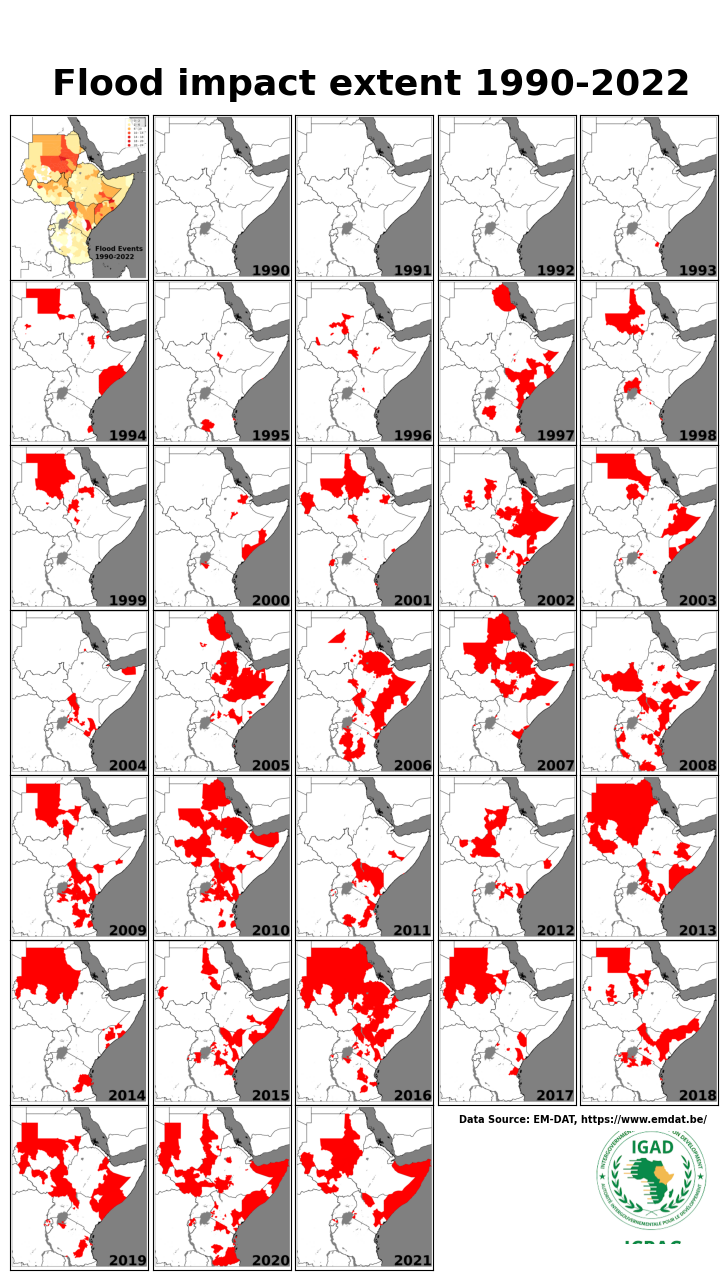

In [7]:
#def order_file(file_list):
#    filepath=os.path.basename(file_list[0])
#    ntpath.basename(file_list).split('.')[0]
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import ntpath

file_list=glob.glob('output/fl/*.png')



def order_file(file_list):
    filepath=os.path.dirname(file_list[0])
    file_list1 = [ntpath.basename(item).split('.')[0] for item in file_list]
    file_list1.sort()
    sorted_file_list=[f'{filepath}/{item}.png' for item in file_list1]
    return sorted_file_list
    
    
ls=order_file(file_list)

fig = plt.figure(figsize=(9.2,15))

#fig, axes = plt.subplots(6, 5)

#ax = [fig.add_subplot(2,2,i+1) for i in range(4)]

#ax = [fig.add_subplot(2,2,i+1) for i in range(4)]

#axes=fig.add_subplot(6,5)

ax = [fig.add_subplot(7,5,i+1) for i in range(35)]

# for idx, row in enumerate(ls):
#     img1 = mpimg.imread(row)
#     axs[idx].imshow(img1)

for axi,img in zip(ax,ls):
    img1=mpimg.imread(img)
    axi.imshow(img1)
    axi.set_aspect('equal')
    axi.set_yticklabels([])
    axi.set_xticklabels([])
    axi.set_xticks([])
    axi.set_yticks([])
    
fig.delaxes(ax[33])
fig.delaxes(ax[34])

sidenote=fig.add_axes([0.52, 0.9, 0.05,0.05], frame_on=False,zorder=0)
sidenote.xaxis.set_ticks_position('none')
sidenote.yaxis.set_ticks_position('none')
sidenote.set_xticklabels('')
sidenote.set_yticklabels('')
plt.text(0,0, 'Flood impact extent 1990-2022',  horizontalalignment='center',fontsize=26,fontweight='bold',color='k', verticalalignment='center',transform =sidenote.transAxes)

sidenote=fig.add_axes([0.75, 0.21, 0.05,0.05], frame_on=False,zorder=0)
sidenote.xaxis.set_ticks_position('none')
sidenote.yaxis.set_ticks_position('none')
sidenote.set_xticklabels('')
sidenote.set_yticklabels('')
plt.text(0,0, 'Data Source: EM-DAT, https://www.emdat.be/',  horizontalalignment='center',fontsize=7,fontweight='bold',color='k', verticalalignment='center',transform =sidenote.transAxes)


logofile = plt.imread('icpac_logo.png')
logo=fig.add_axes([0.76, 0.1, 0.13,0.13], frame_on=False,zorder=0) 
logo.xaxis.set_ticks_position('none')
logo.yaxis.set_ticks_position('none') 
logo.set_xticklabels('')
logo.set_yticklabels('')
logo.imshow(logofile)


plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('output/flood_extent.png', transparent=False,bbox_inches='tight',facecolor='white',dpi=200)
# plt.figure(1)
# plt.subplot(211)
# plt.imshow(img1)

# plt.subplot(212)
# plt.imshow(img2)
# plt.show()


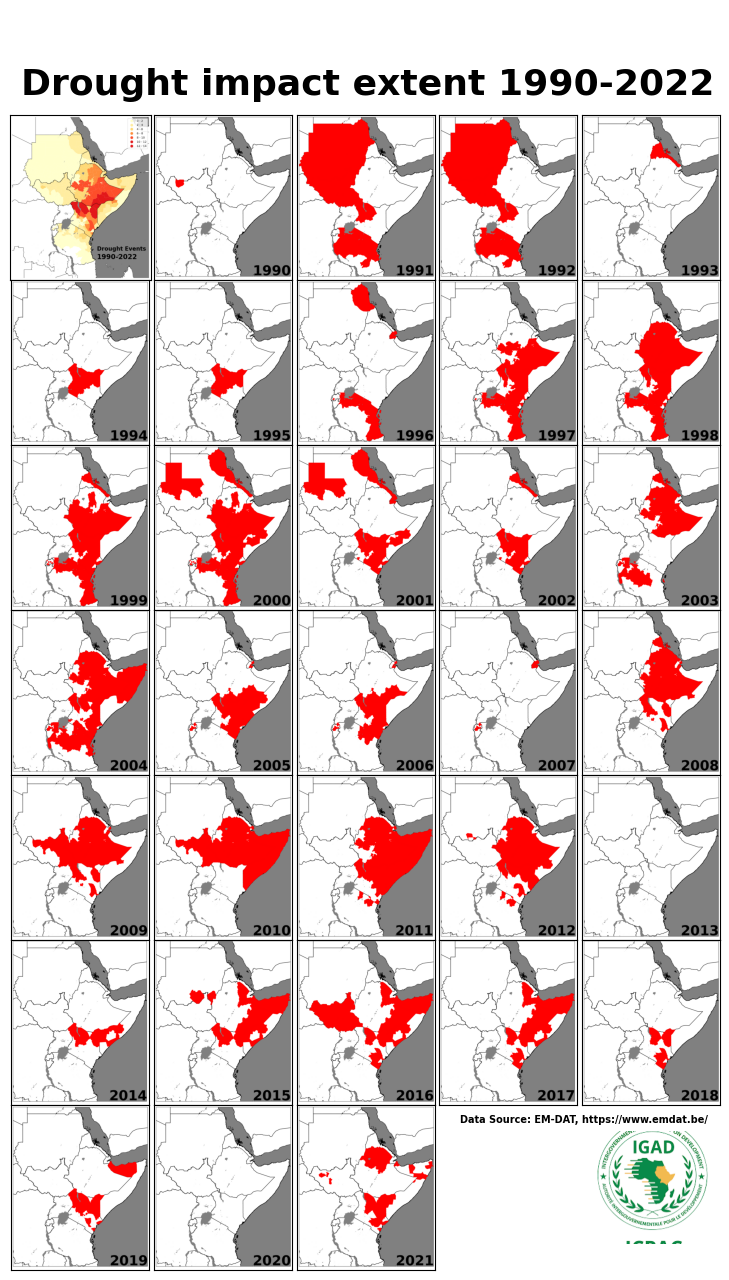

In [8]:

import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import ntpath

file_list=glob.glob('output/dr/*.png')



def order_file(file_list):
    filepath=os.path.dirname(file_list[0])
    file_list1 = [ntpath.basename(item).split('.')[0] for item in file_list]
    file_list1.sort()
    sorted_file_list=[f'{filepath}/{item}.png' for item in file_list1]
    return sorted_file_list
    
    
ls=order_file(file_list)

fig = plt.figure(figsize=(9.2,15))

#fig, axes = plt.subplots(6, 5)

#ax = [fig.add_subplot(2,2,i+1) for i in range(4)]

#ax = [fig.add_subplot(2,2,i+1) for i in range(4)]

#axes=fig.add_subplot(6,5)

ax = [fig.add_subplot(7,5,i+1) for i in range(35)]

# for idx, row in enumerate(ls):
#     img1 = mpimg.imread(row)
#     axs[idx].imshow(img1)

for axi,img in zip(ax,ls):
    img1=mpimg.imread(img)
    axi.imshow(img1)
    axi.set_aspect('equal')
    axi.set_yticklabels([])
    axi.set_xticklabels([])
    axi.set_xticks([])
    axi.set_yticks([])
    
fig.delaxes(ax[33])
fig.delaxes(ax[34])

sidenote=fig.add_axes([0.515, 0.9, 0.05,0.05], frame_on=False,zorder=0)
sidenote.xaxis.set_ticks_position('none')
sidenote.yaxis.set_ticks_position('none')
sidenote.set_xticklabels('')
sidenote.set_yticklabels('')
plt.text(0,0, 'Drought impact extent 1990-2022',  horizontalalignment='center',fontsize=26,fontweight='bold',color='k', verticalalignment='center',transform =sidenote.transAxes)


sidenote=fig.add_axes([0.75, 0.21, 0.05,0.05], frame_on=False,zorder=0)
sidenote.xaxis.set_ticks_position('none')
sidenote.yaxis.set_ticks_position('none')
sidenote.set_xticklabels('')
sidenote.set_yticklabels('')
plt.text(0,0, 'Data Source: EM-DAT, https://www.emdat.be/',  horizontalalignment='center',fontsize=7,fontweight='bold',color='k', verticalalignment='center',transform =sidenote.transAxes)



logofile = plt.imread('icpac_logo.png')
logo=fig.add_axes([0.76, 0.1, 0.13,0.13], frame_on=False,zorder=0) 
logo.xaxis.set_ticks_position('none')
logo.yaxis.set_ticks_position('none') 
logo.set_xticklabels('')
logo.set_yticklabels('')
logo.imshow(logofile)


plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('output/drought_extent.png', transparent=False,bbox_inches='tight',facecolor='white',dpi=200)
# plt.figure(1)
# plt.subplot(211)
# plt.imshow(img1)

# plt.subplot(212)
# plt.imshow(img2)
# plt.show()


## Frequncy map for drought

In [9]:
import geopandas as gp
import pandas as pd
from ast import literal_eval


import cartopy.crs as ccrs
import geopandas as gp
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader

#df_year1

dfa=df_year1.explode('disno1')
dfa['count']=1
dfa1=dfa.groupby('disno1').agg({'count': 'sum'})
dfb1=dfa.groupby('disno1').agg({'year':lambda x: list(x)})
dfa2=dfa1.reset_index()
dfb2=dfb1.reset_index()
#dfa2.sort_values('count')
db=pd.merge(dfa2,dfb2,on='disno1')
db1=db.sort_values('count')
db1.columns=['shapeID','count','year']

dis_no_flat_list=db1['shapeID'].tolist()

#filepath='/home/ea-ibf-climada/impact_catalog/'

filename=f'em_dat_ea_drought_adm2_v2.xlsx'

dfb_dr=pd.read_excel(filename, engine='openpyxl')
#dfb_dr['year']= dfb_dr['Dis No'].str[:4]
#dfb_dr

dfb_dr['adm2_list'] = dfb_dr.geob_adm2_list.apply(lambda x: literal_eval(str(x)))
#dfb_dr['disno_list'] = dfb_dr['Dis No'].apply(lambda x: literal_eval(str(x)))

dfb_dr1=dfb_dr[['Dis No','adm2_list']]

df_b2=dfb_dr1[dfb_dr1['Dis No'].isin(dis_no_flat_list)]
adm2_list0=df_b2['adm2_list'].tolist()
flat_list = [item for sublist in adm2_list0 for item in sublist]

# def get_adm2_list(year,df_year,df_b):
#     df_year1=df_year[df_year['year']==year]
#     dis_no_list=df_year1['disno1'].tolist()
#     dis_no_flat_list = [item for sublist in dis_no_list for item in sublist]
#     df_b2=df_b[df_b['Dis No'].isin(dis_no_flat_list)]
#     adm2_list0=df_b2['adm2_list'].tolist()
#     flat_list = [item for sublist in adm2_list0 for item in sublist]
#     return flat_list

# def get_geodf(list_adm2_year,adm2):
#     adm2_1=adm2[adm2['shapeID'].isin(list_adm2_year)]
#     adm2_1a=adm2_1[['shapeID']]
#     adm2_1a['event']=1.0
#     db=pd.merge(adm2,adm2_1a,on='shapeID',how='right')
#     db1=db[['geometry','event']]
#     return db1


adm2=gp.read_file('ea_adm2_geoboundaries.shp')
adm2_1=adm2[adm2['shapeID'].isin(flat_list)]
adm2_1a=adm2_1[['shapeID']]
adm2_1a['event']=1.0
db=pd.merge(adm2,adm2_1a,on='shapeID',how='right')
db1=db[['geometry','event']]
# edf=pd.merge(adm2,db1,on='shapeID',how='left')
# #db1=db[['geometry','event']]
# #db1=db[db['count'].null()]
# #db1



